# CE49X: Introduction to Computational Thinking and Data Science for Civil Engineers
## Week 2: Python Modules, Strings, and Data Science Tools

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

Based on *A Whirlwind Tour of Python* by Jake VanderPlas (Chapters 13-15)

---

## Table of Contents

1. [Modules and Packages](#1.-Modules-and-Packages)
2. [String Manipulation and Regular Expressions](#2.-String-Manipulation-and-Regular-Expressions)
3. [Preview of Data Science Tools](#3.-Preview-of-Data-Science-Tools)
4. [Practical Engineering Applications](#4.-Practical-Engineering-Applications)
5. [Week 2 Summary and Next Steps](#5.-Week-2-Summary-and-Next-Steps)

---
## 1. Modules and Packages

### Python's "Batteries Included" Philosophy

> **What Makes Python Powerful?**
> - **Built-in modules**: Ready-to-use functionality
> - **Third-party packages**: Extensive ecosystem (100,000+ packages)
> - **Easy installation**: Package managers like pip and conda
> - **Modular design**: Organize code into reusable components

> **Example: Civil Engineering Applications**
> - Access FEM analysis libraries (OpenSeesPy, FEniCS)
> - Use structural design modules (PyNite, StructPy)
> - Integrate with BIM software (IfcOpenShell)
> - Build custom analysis tools for your specific needs

> **Key Insight: Today's Goal**
> Master Python's module system to leverage existing tools and build your own!

### Understanding Modules vs Packages

| | **Module** | **Package** |
|---|---|---|
| **What** | Single Python file (.py) | Directory containing multiple modules |
| **Contains** | Functions, classes, variables | Has `__init__.py` file |
| **Example** | `beam_analysis.py` | `structural/` package |
| **Import** | `import beam_analysis` | Contains many sub-modules |

In [3]:
# Module example: beam_analysis.py
def calculate_moment(load, span):
    return load * span**2 / 8

# Package example structure:
# structural/
#   __init__.py
#   beams.py
#   columns.py
#   loads.py

print("Module = One tool (hammer) | Package = Toolbox (complete set)")

Module = One tool (hammer) | Package = Toolbox (complete set)


### Import Methods: Best Practices

> **1. Explicit Module Import (Recommended)**
> Preserves namespace clarity, easy to trace function origins, prevents naming conflicts.

In [2]:
import math
import statistics

# Clear where functions come from
beam_angle = math.cos(math.pi / 4)  # From math module
load_avg = statistics.mean([10, 15, 20, 25])  # From statistics

print(f"Angle: {beam_angle:.3f}")
print(f"Average load: {load_avg} kN")

Angle: 0.707
Average load: 17.5 kN


### [QUICK] Try it yourself (1 minute)

Import the `datetime` module and print today's date!  
Hint: Use `datetime.date.today()`

In [12]:
import datetime
print(datetime.date.today())

2026-02-23


### Import Aliases for Convenience

> **2. Module Import with Alias**
> Shorter names, standard scientific conventions, maintains namespace separation.

In [ ]:
import numpy as np          # Standard alias
import matplotlib.pyplot as plt  # For plotting
import pandas as pd         # For data analysis

# Standard scientific Python conventions
loads = np.array([120, 145, 98, 167, 134])  # kN
stresses = loads / 25  # MPa (assuming area = 25 cm^2)

print(f"Max stress: {np.max(stresses):.1f} MPa")
print(f"Mean stress: {np.mean(stresses):.1f} MPa")

> **Example: Community Conventions**
> - `np` = NumPy (always)
> - `pd` = Pandas (always)
> - `plt` = Matplotlib.pyplot (always)
> - Following these makes your code instantly recognizable!

### Selective Imports

> **3. Import Specific Functions**
> Import only what you need, cleaner code, good for frequently used functions.

In [ ]:
from math import cos, sin, pi, sqrt
from statistics import mean, stdev

# Structural vibration calculation
frequency = 2.5  # Hz
period = 1 / frequency
angle = 2 * pi * frequency * 0.1  # at t=0.1s

# Direct use without module prefix
amplitude = 10 * cos(angle)  # mm
velocity = -10 * 2 * pi * frequency * sin(angle)  # mm/s

print(f"Displacement: {amplitude:.2f} mm")
print(f"Velocity: {velocity:.2f} mm/s")

### [DEBUG] Common Pitfall

What happens if you do: `from numpy import *` and then `sum([1, 2, 3])`?  
The NumPy `sum` overwrites Python's built-in `sum`!

In [ ]:
# Try it and observe the difference


### [LIVE] Coding Challenge: Module Organization

**Your Task (4 minutes):**
Create a structural analysis module organization:
- Define functions for beam moment, shear, and deflection
- Import and use them correctly
- Calculate values for a 6m beam with 10 kN/m load

In [13]:
# Define your analysis functions
def calculate_moment(w, L):
    # YOUR CODE HERE: return max moment for simply supported beam
    return w*L**2/8

def calculate_shear(w, L):
    # YOUR CODE HERE: return max shear
    return w*L/2

def calculate_deflection(w, L, E=200000, I=8333):
    # YOUR CODE HERE: return max deflection
    L_mm = L * 1000          # m → mm
    I_mm4 = I * 10**4        # cm4 → mm4
    return (5 * w * (L_mm**4)) / (384 * E * I_mm4)

# Test with: w=10 kN/m, L=6m
w = 10
L = 6

print("Moment:", calculate_moment(w, L), "kNm")
print("Shear:", calculate_shear(w, L), "kN")
print("Deflection:", calculate_deflection(w, L), "mm")


Moment: 45.0 kNm
Shear: 30.0 kN
Deflection: 10.125405016200649 mm


### Import Wildcards: When to Avoid

> **4. Wildcard Imports (Generally Avoid)**
> `from module import *` imports everything, can overwrite functions, makes debugging harder.

> **Example: The Problem - A Real Debugging Nightmare**
> - Python's `sum([1, 2, 3])` returns 6
> - NumPy's `sum([1, 2, 3])` returns `numpy.int64(6)`
> - Different behavior can break your code silently!

> **Key Insight: Best Practice**
> - **Good**: `import numpy as np` or `from math import sin, cos`
> - **Bad**: `from numpy import *`
> - Exception: Interactive exploration in Jupyter (but fix before production)

### Essential Standard Library Modules for Engineers

| Category | Module | Use Case |
|---|---|---|
| **Mathematical & Scientific** | `math` | Trigonometry, logarithms |
| | `statistics` | Mean, stdev, regression |
| | `random` | Monte Carlo simulations |
| | `cmath` | Complex numbers (signals) |
| **Data Processing** | `csv` | Read sensor data files |
| | `json` | API data exchange |
| | `pickle` | Save Python objects |
| **System & File Operations** | `os` | File system navigation |
| | `pathlib` | Modern path handling |
| | `datetime` | Time series data |
| **Advanced Tools** | `itertools` | Combinations, permutations |
| | `functools` | Caching, decorators |
| | `urllib` | Download data from web |

### [PRACTICE] Try This Now (2 minutes)

Import `random` and generate 5 random concrete strengths between 20-40 MPa.

In [17]:
import random
for i in range(5):
    strength= random.randint(20,40)
    print (strength, "MPa")


# YOUR CODE HERE


34 MPa
23 MPa
20 MPa
39 MPa
35 MPa


### [TOGETHER] Installing Third-Party Packages

> **Package Installation Methods**
> - **pip**: `pip install numpy scipy matplotlib`
> - **conda**: `conda install numpy scipy matplotlib`
> - **Virtual environments**: Isolated project dependencies

In [ ]:
# Check installed packages
import sys
print(f"Python version: {sys.version}")

# In Jupyter/Colab you can run:
# !pip list | grep numpy
# Install specific version: pip install numpy==1.21.0
# Install from requirements: pip install -r requirements.txt

> **Example: Engineering Package Examples**
> - `pip install openseespy`  -- Structural analysis
> - `pip install pynite`      -- Frame analysis
> - `pip install ifcopenshell` -- BIM/IFC files

> **Key Insight: Professional Tip**
> Create a `requirements.txt` file for each project to track dependencies!

---
## 2. String Manipulation and Regular Expressions

### Why String Processing Matters in Engineering

> **Common Engineering String Tasks**
> - **Data Import**: Reading CSV files, parsing measurement data
> - **Report Generation**: Creating formatted output documents
> - **File Processing**: Handling CAD files, analysis output files
> - **Data Validation**: Checking input formats, units, ranges
> - **Database Operations**: SQL queries, data cleaning

> **Example: Real-World Examples**
> - Parsing bridge inspection reports from text files
> - Extracting coordinates from survey data
> - Formatting structural analysis results for presentations
> - Processing weather station data files
> - Converting between different data formats

### Python String Fundamentals

> **String Definition Options**
> - **Single quotes**: `'Steel Grade 250'`
> - **Double quotes**: `"Concrete fc'=30"` (use when string contains `'`)
> - **Triple quotes**: Multi-line strings, docstrings
> - **Raw strings**: `r"C:\Bridge\Data\sensors.csv"` (no escapes)

In [18]:
# Engineering data with different string types
material = 'reinforced concrete'  # Simple string
spec = "fc'=30 MPa"  # Contains apostrophe -- why double quotes?
report = """Structural Analysis Report
Date: 2025-01-15
Project: Highway Bridge"""

# File paths - always use raw strings on Windows!
data_file = r"C:\Projects\Bridge_2025\load_data.csv"  # Correct
# bad_path = "C:\Projects\Bridge_2025\load_data.csv"  # Will fail!

print(material)
print(spec)
print(report)
print(f"\nData file path: {data_file}")

reinforced concrete
fc'=30 MPa
Structural Analysis Report
Date: 2025-01-15
Project: Highway Bridge

Data file path: C:\Projects\Bridge_2025\load_data.csv


### [DEBUG] Common Error

What's wrong with: `path = "C:\newfolder\test.txt"`?  
The `\n` becomes a newline! Use raw strings: `r"C:\newfolder\test.txt"`

In [21]:
path = r"C:\newfolder\test.txt"
print(path)


C:\newfolder\test.txt


### Essential String Methods for Engineering Data

In [19]:
# Processing messy engineering data -- Predict the outputs!
material = "  REINFORCED conCRETE  "
clean = material.strip().title()
print(clean)

# Parsing member IDs
member_id = "BEAM-B01-LEVEL3"
parts = member_id.split('-')  # ['BEAM', 'B01', 'LEVEL3']
beam_type = parts[0].lower()  # 'beam'
beam_num = parts[1]  # 'B01'
print(f"Parts: {parts}")
print(f"Type: {beam_type}, Number: {beam_num}")

# Replacing units
measurement = "Load: 1500 kips"
metric = measurement.replace('kips', 'kN')
value = float(measurement.split()[1]) * 4.448  # Convert to kN
print(f"Metric: {value:.1f} kN")

Reinforced Concrete
Parts: ['BEAM', 'B01', 'LEVEL3']
Type: beam, Number: B01
Metric: 6672.0 kN


> **Key Insight: Key String Methods**
> `.strip()` removes whitespace | `.split()` creates list | `.join()` combines list | `.replace()` substitutes text

### [PRACTICE] String Cleaning Challenge

**Your Task (3 minutes):**
Clean and standardize this sensor data to the format `"S##: value MPa"`

Hints:
1. Extract sensor number
2. Extract value
3. Standardize units to "MPa"
4. Format as "S##: value MPa"

In [22]:
# Messy sensor readings
data = [
    "  Sensor_01: 125.3 mPa  ",
    "sensor_02:98.7mpa",
    "SENSOR_03 : 145.2 MPA",
    "  sensor-04: 112.8 Mpa"
]

import re
# YOUR TASK: Clean and standardize to format "S01: 125.3 MPa"
for reading in data:
    # YOUR CODE HERE
    clean = reading.strip().lower()

    num = re.findall(r'\d+', clean)[0]
    value = re.findall(r'\d+\.\d+', clean)[0]

    print(f"S{num}: {value} MPa")

S01: 125.3 MPa
S02: 98.7 MPa
S03: 145.2 MPa
S04: 112.8 MPa


### Modern String Formatting: f-strings

> **Why f-strings? (Python 3.6+)**
> Readable, fast, supports expressions, type formatting

In [23]:
# Engineering calculations with formatted output
beam_id = "B-001"
moment = 245.678  # kN*m
capacity = 300  # kN*m
utilization = moment / capacity * 100

# f-string with expressions -- Try changing precision!
report = f"""Beam Analysis Report
ID: {beam_id}
Moment: {moment:.1f} kN*m
Capacity: {capacity} kN*m
Utilization: {utilization:.1f}%
Status: {'OK' if utilization < 90 else 'CHECK REQUIRED'}"""

print(report)

# Advanced formatting
pi_value = 3.14159265
print(f"\nPi to 3 decimals: {pi_value:.3f}")
print(f"Percentage: {0.856:.1%}")  # Automatic % conversion!
print(f"Scientific: {1234567:.2e}")

Beam Analysis Report
ID: B-001
Moment: 245.7 kN*m
Capacity: 300 kN*m
Utilization: 81.9%
Status: OK

Pi to 3 decimals: 3.142
Percentage: 85.6%
Scientific: 1.23e+06


### Regular Expressions

> **What are Regular Expressions?**
> Pattern matching for complex text processing: find patterns, validate formats, extract data.

> **Example: Engineering Applications**
> - Extract dimensions: "200x400x6000mm"
> - Validate formats: coordinates, member IDs, loads
> - Parse log files and reports
> - Clean measurement data

> **Key Insight: Learning Tip**
> Start with simple patterns, build complexity gradually.

### [LIVE] Regular Expressions for Engineering Data

> **Pattern Matching Power**
> Extract complex patterns from text: measurements, IDs, coordinates

In [24]:
import re

# Engineering report with mixed data
report = """Bridge inspection 2025-01-15:
Beam B-001: 250x400mm, stress 145.3 MPa
Column C-42A: 600x600mm, load 1250.5 kN
Coordinates: (42.3567, -71.0589)
Next inspection: 2025-07-15"""

# Extract all measurements with units -- Try these patterns!
nums_with_units = re.findall(r'\d+\.?\d*\s*(?:mm|MPa|kN)', report)
print("Measurements:", nums_with_units)

# Extract member IDs (letter-numbers-optional letter)
member_ids = re.findall(r'[A-Z]-\d+[A-Z]?', report)
print("Members:", member_ids)

# Extract dates (YYYY-MM-DD)
dates = re.findall(r'\d{4}-\d{2}-\d{2}', report)
print("Dates:", dates)

Measurements: ['400mm', '145.3 MPa', '600mm', '1250.5 kN']
Members: ['B-001', 'C-42A']
Dates: ['2025-01-15', '2025-07-15']


### [DEBUG] Together: Fix the Regex Patterns

**Collaborative Debugging (4 minutes):**
These patterns have bugs. Let's fix them together!

In [26]:
import re

# Bug #1: Coordinate extraction (handles parentheses, spaces, and negative values)
coords = "Location: (42.3567, -71.0589) and (40.7128, -74.006)"
pattern1 = r'\(\s*-?\d+\.\d+\s*,\s*-?\d+\.\d+\s*\)'

# Bug #2: Dimension extraction (captures 2D or 3D dimensions and includes 'mm')
dims = "Steel section: 200x300x6000mm, Concrete: 400x800mm"
pattern2 = r'\d+x\d+(?:x\d+)?mm'

# Bug #3: Load value extraction (supports decimals + optional space before kN)
loads = "Dead: 125.5kN, Live: 85 kN, Wind: 42.75kN"
pattern3 = r'\d+(?:\.\d+)?\s*kN'

# Test and show results
print("Coords found:", re.findall(pattern1, coords))
print("Dimensions found:", re.findall(pattern2, dims))
print("Loads found:", re.findall(pattern3, loads))

Coords found: ['(42.3567, -71.0589)', '(40.7128, -74.006)']
Dimensions found: ['200x300x6000mm', '400x800mm']
Loads found: ['125.5kN', '85 kN', '42.75kN']


**Discuss: What patterns did you find? How would you fix them?**

### [COMPETITION] Regex Challenge: Data Extraction Race

**Mini-Competition (5 minutes):**
Extract all required data from this construction log. Most complete and efficient wins!

**Your Challenge -- Extract:**
1. All timestamps (YYYY-MM-DD HH:MM:SS)
2. All section IDs (A1-B2 format)
3. All measurements with units
4. All ID numbers (ID#XXXX or CT-XXXX)

Scoring: Correctness (50%), Code efficiency (30%), Readability (20%)

In [28]:
import re

log = """2025-01-15 08:30:45 - Pour started: Section A1-B2
Concrete: fc'=35MPa, Slump: 150mm, Temp: 22.5C
Volume: 45.5m3, Truck#: CT-2847, Driver: ID#8934
2025-01-15 11:45:20 - Pour complete: Section A1-B2
Total time: 3.25hrs, Weather: Clear, 18.5C
Next pour: Section B2-C3, Date: 2025-01-16"""

# YOUR CHALLENGE:
# 1. All timestamps (YYYY-MM-DD HH:MM:SS)
# 2. All section IDs (A1-B2 format)
# 3. All measurements with units
# 4. All ID numbers (ID#XXXX or CT-XXXX)

# YOUR CODE HERE - Aim for elegance!
# 1️⃣ timestamps (YYYY-MM-DD HH:MM:SS)
timestamps = re.findall(r'\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}', log)

# 2️⃣ section IDs (A1-B2 format)
sections = re.findall(r'[A-Z]\d-[A-Z]\d', log)

# 3️⃣ measurements with units
measurements = re.findall(r'\d+\.?\d*\s*(?:MPa|mm|m3|C|hrs)', log)

# 4️⃣ ID numbers (ID#XXXX or CT-XXXX)
ids = re.findall(r'(?:ID#\d+|CT-\d+)', log)

print("Timestamps:", timestamps)
print("Sections:", sections)
print("Measurements:", measurements)
print("IDs:", ids)


Timestamps: ['2025-01-15 08:30:45', '2025-01-15 11:45:20']
Sections: ['A1-B2', 'A1-B2', 'B2-C3']
Measurements: ['2\nC', '35MPa', '150mm', '22.5C', '45.5m3', '3.25hrs', '18.5C']
IDs: ['CT-2847', 'ID#8934']


---
## 3. Preview of Data Science Tools

### The Scientific Python Ecosystem

| Layer | Libraries |
|---|---|
| Specialized | OpenSeesPy, FEniCS, PyNite |
| Application | Pandas, Scikit-learn, SymPy, Jupyter |
| Foundation | NumPy, SciPy, Matplotlib |
| Core | Python Core Language |

> **Key Insight: Build on Giants' Shoulders**
> Don't reinvent the wheel -- use tested, optimized libraries!

### NumPy: Foundation of Scientific Python

> **Key Features**
> N-dimensional arrays, vectorized operations, linear algebra, 10-100x faster than Python lists.

> **Example: Engineering Applications**
> - Store sensor measurement data
> - Represent structural matrices
> - Perform finite element calculations
> - Process time-series monitoring data

### [LIVE] NumPy: Foundation of Scientific Computing

> **Why NumPy?**
> 10-100x faster than Python lists, foundation for all scientific libraries

In [29]:
import numpy as np

# Structural loads analysis -- Predict: What's the speedup?
loads_list = [120, 145, 98, 167, 134]  # Python list
loads_array = np.array(loads_list)      # NumPy array

# Compare operations
# Python way (slow)
factored_list = [x * 1.5 for x in loads_list]

# NumPy way (fast) - vectorized!
factored_array = loads_array * 1.5  # All at once!

print(f"Max load: {np.max(loads_array)} kN")
print(f"Mean: {np.mean(loads_array):.1f} kN")
print(f"Std Dev: {np.std(loads_array):.1f} kN")

# Matrix operations for structural analysis
K = np.array([[1000, -500], [-500, 1000]])  # Stiffness matrix
F = np.array([100, 50])  # Force vector
u = np.linalg.solve(K, F)  # Solve K*u = F
print(f"Displacements: {u}")

Max load: 167 kN
Mean: 132.8 kN
Std Dev: 23.2 kN
Displacements: [0.16666667 0.13333333]


### [PRACTICE] NumPy Challenge: Beam Analysis

**Your Task (4 minutes):**
Use NumPy to analyze a simply supported beam with multiple point loads.

Hint: For a simply supported beam:  
$R_A = \frac{\sum P_i \cdot (L - x_i)}{L}$  
$M(x) = R_A \cdot x - \sum P_i$ for loads before $x$

In [30]:
import numpy as np

# Beam data
L = 10  # meters
loads = np.array([50, 30, 40, 20])  # kN
positions = np.array([2, 4, 6, 8])  # meters from left support

# YOUR TASK:
# 1. Calculate reactions at supports (RA and RB)
# 2. Calculate moment at each load position
# 3. Find maximum moment and its location

# Hint: For simply supported beam:
# RA = sum(P * (L - x)) / L
# M(x) = RA * x - sum(P) for loads before x

# YOUR CODE HERE
# 1) Reactions (RA and RB)
RA = np.sum(loads * (L - positions)) / L
RB = np.sum(loads * positions) / L   # veya: loads.sum() - RA

print(f"RA = {RA:.2f} kN")
print(f"RB = {RB:.2f} kN")

# 2) Moment at each load position
# M(x) = RA*x - sum(P_i*(x - x_i)) for loads with x_i <= x
moments = []
for x in positions:
    mask = positions <= x
    Mx = RA * x - np.sum(loads[mask] * (x - positions[mask]))
    moments.append(Mx)

moments = np.array(moments)

print("\nMoments at load positions (kN*m):")
for x, M in zip(positions, moments):
    print(f"x={x:.1f} m -> M={M:.2f} kN*m")

# 3) Maximum moment and its location (scan beam)
x_grid = np.linspace(0, L, 2001)
M_grid = np.zeros_like(x_grid)

for i, x in enumerate(x_grid):
    mask = positions <= x
    M_grid[i] = RA * x - np.sum(loads[mask] * (x - positions[mask]))

idx = np.argmax(M_grid)
print(f"\nMaximum moment: {M_grid[idx]:.2f} kN*m at x={x_grid[idx]:.3f} m")


RA = 78.00 kN
RB = 62.00 kN

Moments at load positions (kN*m):
x=2.0 m -> M=156.00 kN*m
x=4.0 m -> M=212.00 kN*m
x=6.0 m -> M=208.00 kN*m
x=8.0 m -> M=124.00 kN*m

Maximum moment: 212.00 kN*m at x=4.000 m


### Pandas: Data Analysis

> **Key Features**
> DataFrame structures, data cleaning, import/export (CSV, Excel), grouping, time series.

> **Example: Engineering Applications**
> - Import sensor data and test results
> - Analyze time series monitoring
> - Create statistical summaries
> - Generate analysis reports

> **Key Insight: Why Pandas?**
> Excel-like functionality with Python power and reproducibility.

### [TOGETHER] Pandas: Data Analysis Made Easy

In [31]:
import pandas as pd
import numpy as np

# Create concrete test data -- Follow along!
concrete_data = {
    'sample_id': ['C001', 'C002', 'C003', 'C004', 'C005'],
    'age_days': [7, 7, 28, 28, 28],
    'strength_mpa': [18.5, 19.2, 28.3, 31.5, 29.8],
    'mix_type': ['A', 'A', 'B', 'B', 'B']
}

df = pd.DataFrame(concrete_data)
print(df)

# Analysis operations
print(f"\nMean 28-day strength: {df[df['age_days']==28]['strength_mpa'].mean():.1f} MPa")

# Group by mix type
stats = df.groupby('mix_type')['strength_mpa'].agg(['mean', 'std', 'count'])
print("\nStatistics by mix:")
print(stats)

# Add compliance check
df['compliant'] = df['strength_mpa'] >= 25
print(f"\nCompliance rate: {df['compliant'].mean():.1%}")

  sample_id  age_days  strength_mpa mix_type
0      C001         7          18.5        A
1      C002         7          19.2        A
2      C003        28          28.3        B
3      C004        28          31.5        B
4      C005        28          29.8        B

Mean 28-day strength: 29.9 MPa

Statistics by mix:
               mean       std  count
mix_type                            
A         18.850000  0.494975      2
B         29.866667  1.601041      3

Compliance rate: 60.0%


### Matplotlib: Scientific Visualization

> **Key Features**
> Publication-quality plots, wide variety of chart types, complete customization, multiple output formats.

> **Example: Engineering Visualizations**
> - Load-displacement curves
> - Time series sensor data
> - Stress distribution plots
> - Material property distributions
> - Project progress charts

### [LIVE] Matplotlib: Publication-Quality Plots

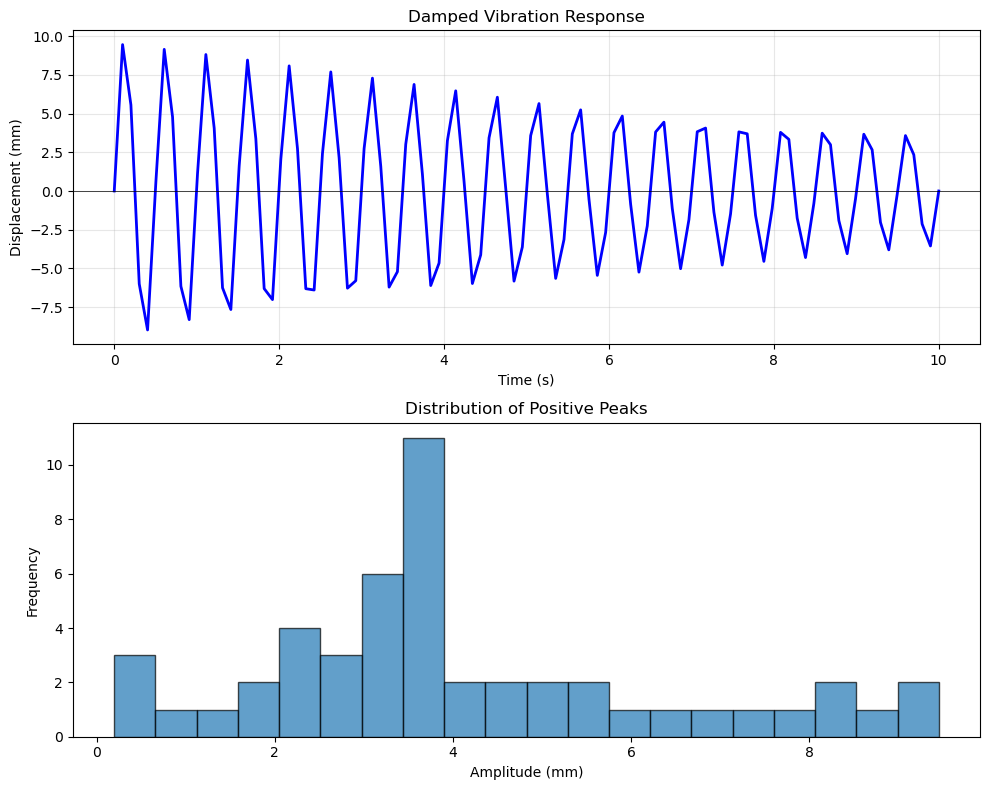

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Generate structural response data -- Try different parameters!
time = np.linspace(0, 10, 100)  # seconds
frequency = 2.0  # Hz
damping = 0.1
amplitude = 10 * np.exp(-damping * time) * np.sin(2 * np.pi * frequency * time)

# Create professional plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Time series
ax1.plot(time, amplitude, 'b-', linewidth=2)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Displacement (mm)')
ax1.set_title('Damped Vibration Response')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

# Histogram of peaks
peaks = amplitude[amplitude > 0]
ax2.hist(peaks, bins=20, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Amplitude (mm)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Positive Peaks')

plt.tight_layout()
plt.show()

### [QUICK] SciPy: Advanced Scientific Computing

> **Key Capabilities**
> Optimization, curve fitting, interpolation, integration, signal processing

In [33]:
from scipy import optimize, interpolate
import numpy as np

# Curve fitting example - concrete strength vs time
days = np.array([3, 7, 14, 28, 56])
strength = np.array([12, 20, 26, 30, 32])  # MPa

# Fit exponential model: f(t) = a * (1 - exp(-b*t))
def model(t, a, b):
    return a * (1 - np.exp(-b * t))

params, _ = optimize.curve_fit(model, days, strength)
print(f"Model: f(t) = {params[0]:.1f} * (1 - exp(-{params[1]:.3f}*t))")

# Interpolation for intermediate values
interp_func = interpolate.interp1d(days, strength, kind='cubic')
day_21_strength = interp_func(21)
print(f"Predicted 21-day strength: {day_21_strength:.1f} MPa")

Model: f(t) = 24.0 * (1 - exp(-8.769*t))
Predicted 21-day strength: 28.7 MPa


C:\Users\seker\AppData\Local\Temp\ipykernel_19952\823892141.py:10: RuntimeWarning: overflow encountered in exp
  return a * (1 - np.exp(-b * t))
C:\Users\seker\AppData\Local\Temp\ipykernel_19952\823892141.py:12: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = optimize.curve_fit(model, days, strength)


> **Key Insight: Pair Exercise (2 minutes)**
> With your neighbor: What other SciPy functions would be useful for structural analysis?

### [EXPLORE] Specialized Engineering Packages

| Category | Package | Description |
|---|---|---|
| **Structural Analysis** | `OpenSeesPy` | Earthquake engineering |
| | `PyNite` | 3D frame analysis |
| | `anaStruct` | 2D frame analysis |
| | `FEniCS` | Finite element modeling |
| **Data & Visualization** | `Plotly` | Interactive plots |
| | `Seaborn` | Statistical graphics |
| | `Bokeh` | Web visualizations |
| **BIM & CAD** | `IfcOpenShell` | IFC file handling |
| | `PythonOCC` | CAD kernel |
| | `FreeCAD API` | CAD automation |
| **Utilities** | `Pint` | Unit conversions |
| | `SymPy` | Symbolic math |
| | `Uncertainties` | Error propagation |

**[DISCUSS] Class Poll:** Which package sounds most useful for your projects? Why?

### [TOGETHER] Getting Started with Data Science

> **Installation Options**
> - **Anaconda**: Complete scientific distribution (recommended)
> - **Miniconda**: Minimal conda installer
> - **pip + venv**: Traditional Python approach

In [34]:
# Check your setup
import sys
print(f"Python: {sys.version}")

# Check essential packages
try:
    import numpy as np
    import pandas as pd
    import matplotlib
    print("Essential packages installed!")
    print(f"NumPy version: {np.__version__}")
except ImportError as e:
    print(f"Missing package: {e}")

Python: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Essential packages installed!
NumPy version: 2.3.5


> **Key Insight: Professional Workflow**
> 1. Create virtual environment | 2. Install packages | 3. Save requirements.txt | 4. Version control

---
## 4. Practical Engineering Applications

### Real Engineering Workflow: From Data to Decision

> **Complete Data Science Pipeline**
> 1. **Import**: Multiple data sources (CSV, Excel, databases)
> 2. **Clean**: Handle missing values, outliers, units
> 3. **Transform**: Calculate derived properties
> 4. **Analyze**: Statistical analysis, pattern detection
> 5. **Visualize**: Create publication-quality figures
> 6. **Report**: Generate automated reports

> **Example: Today's Case Study**
> Bridge monitoring data: 1000+ sensors, 6 months of data, multiple formats
> - Challenge: Identify anomalies and predict maintenance needs
> - Tools: Pandas for processing, NumPy for calculations, Matplotlib for visualization

> **Key Insight: Industry Reality**
> 80% of data science is data cleaning -- let's automate it!

### [COMPETITION] Data Pipeline Challenge

**Team Competition (7 minutes):**
Build the most efficient concrete quality control pipeline!

**Your Challenge:**
1. Clean the data (handle 'N/A', convert types)
2. Calculate strength gain ratio (28d/7d)
3. Flag non-compliant batches (28d < 30 MPa)
4. Find correlation between w/c ratio and strength
5. Create summary statistics by cement content group

Most complete and elegant wins!

In [37]:
import pandas as pd
import numpy as np

# Sample data
data = {
    'batch_id': ['B001', 'B002', 'B003', 'B004', 'B005'],
    'strength_7d': [18.5, 'N/A', 21.3, 19.8, 22.1],
    'strength_28d': [28.3, 31.5, '29.8', 27.2, 33.4],
    'cement_kg': [320, 350, 340, 330, 360],
    'water_cement': [0.45, 0.42, 0.43, 0.44, 0.40]
}

# YOUR CHALLENGE:
# 1. Clean the data (handle 'N/A', convert types)
# 2. Calculate strength gain ratio (28d/7d)
# 3. Flag non-compliant batches (28d < 30 MPa)
# 4. Find correlation between w/c ratio and strength
# 5. Create summary statistics by cement content group

# YOUR CODE HERE - Most complete & elegant wins!
# 1) Clean the data (handle 'N/A', convert types)
df = pd.DataFrame(data)

# 'N/A' -> NaN, then numeric
df['strength_7d'] = pd.to_numeric(df['strength_7d'], errors='coerce')
df['strength_28d'] = pd.to_numeric(df['strength_28d'], errors='coerce')
df['cement_kg'] = pd.to_numeric(df['cement_kg'], errors='coerce')
df['water_cement'] = pd.to_numeric(df['water_cement'], errors='coerce')

print("Cleaned data:")
print(df)

# 2) Calculate strength gain ratio (28d / 7d)
df['gain_ratio_28d_7d'] = df['strength_28d'] / df['strength_7d']

# 3) Flag non-compliant batches (28d < 30 MPa)
df['non_compliant_28d'] = df['strength_28d'] < 30

print("\nWith gain ratio + compliance flag:")
print(df[['batch_id', 'strength_7d', 'strength_28d', 'gain_ratio_28d_7d', 'non_compliant_28d']])

# 4) Correlation between w/c ratio and strength (use rows where both exist)
corr_wc_28d = df[['water_cement', 'strength_28d']].dropna().corr().iloc[0, 1]
corr_wc_7d  = df[['water_cement', 'strength_7d']].dropna().corr().iloc[0, 1]

print(f"\nCorrelation(w/c, 28d strength) = {corr_wc_28d:.3f}")
print(f"Correlation(w/c, 7d strength)  = {corr_wc_7d:.3f}")

# 5) Summary statistics by cement content group
# (example grouping: low <330, mid 330-349, high >=350)
bins = [0, 330, 350, np.inf]
labels = ['low(<330)', 'mid(330-349)', 'high(>=350)']
df['cement_group'] = pd.cut(df['cement_kg'], bins=bins, labels=labels, right=False)

summary = (df
           .groupby('cement_group')
           .agg(
               n=('batch_id', 'count'),
               mean_7d=('strength_7d', 'mean'),
               mean_28d=('strength_28d', 'mean'),
               mean_gain=('gain_ratio_28d_7d', 'mean'),
               noncompliant_rate=('non_compliant_28d', 'mean'),
               mean_wc=('water_cement', 'mean')
           )
          )

print("\nSummary by cement group:")
print(summary)

# Optional: show which batches are non-compliant
print("\nNon-compliant batches (28d < 30 MPa):")
print(df.loc[df['non_compliant_28d'], ['batch_id', 'strength_28d']])


Cleaned data:
  batch_id  strength_7d  strength_28d  cement_kg  water_cement
0     B001         18.5          28.3        320          0.45
1     B002          NaN          31.5        350          0.42
2     B003         21.3          29.8        340          0.43
3     B004         19.8          27.2        330          0.44
4     B005         22.1          33.4        360          0.40

With gain ratio + compliance flag:
  batch_id  strength_7d  strength_28d  gain_ratio_28d_7d  non_compliant_28d
0     B001         18.5          28.3           1.529730               True
1     B002          NaN          31.5                NaN              False
2     B003         21.3          29.8           1.399061               True
3     B004         19.8          27.2           1.373737               True
4     B005         22.1          33.4           1.511312              False

Correlation(w/c, 28d strength) = -0.937
Correlation(w/c, 7d strength)  = -0.917

Summary by cement group:
         

C:\Users\seker\AppData\Local\Temp\ipykernel_19952\2376798785.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('cement_group')


### [LIVE] Complete Analysis Pipeline

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Real-world pipeline -- Follow along and modify!
def analyze_concrete_data(df):
    """Analyze concrete test data from a DataFrame."""
    # Clean
    df['strength'] = pd.to_numeric(df['strength'], errors='coerce')
    df = df.dropna(subset=['strength'])

    # Transform
    df['strength_ratio'] = df['strength'] / df['target_strength']
    df['compliance'] = df['strength_ratio'] >= 1.0

    # Analyze
    summary = {
        'total_samples': len(df),
        'mean_strength': df['strength'].mean(),
        'std_strength': df['strength'].std(),
        'compliance_rate': df['compliance'].mean(),
        'critical_samples': df[~df['compliance']]['sample_id'].tolist()
    }

    return df, summary

# Create inline test data instead of reading from CSV
test_data = pd.DataFrame({
    'sample_id': ['S001', 'S002', 'S003', 'S004', 'S005', 'S006'],
    'strength': [28.5, 31.2, 24.8, 30.1, 'N/A', 27.3],
    'target_strength': [30, 30, 30, 30, 30, 30]
})

df_result, results = analyze_concrete_data(test_data)
print("Analysis Results:")
for key, val in results.items():
    print(f"  {key}: {val}")

Analysis Results:
  total_samples: 5
  mean_strength: 28.380000000000003
  std_strength: 2.4953957601951635
  compliance_rate: 0.4
  critical_samples: ['S001', 'S003', 'S006']


C:\Users\seker\AppData\Local\Temp\ipykernel_19952\1381073190.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['strength_ratio'] = df['strength'] / df['target_strength']
C:\Users\seker\AppData\Local\Temp\ipykernel_19952\1381073190.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['compliance'] = df['strength_ratio'] >= 1.0


---
## 5. Week 2 Summary and Next Steps

### What We've Covered This Week

| Topic | Key Concepts |
|---|---|
| **Modules & Packages** | Import strategies and best practices, Standard library modules, Package installation with pip/conda, Creating modular code |
| **String Processing** | String methods for data cleaning, Modern formatting with f-strings, Regular expressions for pattern matching, Text extraction from engineering data |
| **Data Science Foundations** | NumPy for numerical computing, Pandas for data analysis, Matplotlib for visualization, SciPy for scientific computing |
| **Practical Applications** | Complete data pipelines, Engineering data processing, Quality control automation, Report generation |

### Key Programming Concepts Mastered

> **Key Insight: Core Python Skills**
> - **Modular Programming**: Organizing code with modules and packages
> - **Text Processing**: String manipulation and regex for data extraction
> - **Scientific Computing**: NumPy arrays and vectorized operations
> - **Data Analysis**: Pandas DataFrames for structured data
> - **Visualization**: Creating publication-quality plots

> **Example: Engineering Problem-Solving Skills**
> - Process sensor data from multiple sources
> - Clean and standardize messy engineering data
> - Perform statistical analysis on test results
> - Create automated quality control pipelines
> - Generate professional technical reports

---

### Questions?

**Thank you!**

Dr. Eyuphan Koc  
eyuphan.koc@bogazici.edu.tr